# IMPORT AND PREPARE DATA
1. Import libraries
2. Import skempi dataset
3. Import s4169 dataset
4. Create PDB ID column in skempi dataset
5. Create Chain column in s4169 and skempi datasets

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
file_path = '/content/drive/MyDrive/skempi_v2.csv'
try:
    skempi = pd.read_csv(file_path, delimiter=";")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

In [ ]:
skempi.shape

(7085, 29)

In [ ]:
file_path = '/content/drive/MyDrive/dati/mCSM-PPI2.csv'
try:
    s4169 = pd.read_csv(file_path, delimiter="\t")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

In [ ]:
s4169.shape

(4169, 5)

In [ ]:
ids = skempi['#Pdb'].to_list()
i = 0
for i in range(len(ids)):
  ids[i] = ids[i].split('_')[0]
skempi['PDB'] = ids
skempi.head()

,#Pdb,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Hold_out_type,Hold_out_proteins,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,...,koff_wt (s^(-1)),koff_wt_parsed,dH_mut (kcal mol^(-1)),dH_wt (kcal mol^(-1)),dS_mut (cal mol^(-1) K^(-1)),dS_wt (cal mol^(-1) K^(-1)),Notes,Method,SKEMPI version,PDB
0,1CSE_E_I,LI45G,LI38G,COR,Pr/PI,Pr/PI,5.26E-11,5.260000e-11,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,1CSE
1,1CSE_E_I,LI45S,LI38S,COR,Pr/PI,Pr/PI,8.33E-12,8.330000e-12,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,1CSE
2,1CSE_E_I,LI45P,LI38P,COR,Pr/PI,Pr/PI,1.02E-07,1.020000e-07,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,1CSE
3,1CSE_E_I,LI45I,LI38I,COR,Pr/PI,Pr/PI,1.72E-10,1.720000e-10,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,1CSE
4,1CSE_E_I,LI45D,LI38D,COR,Pr/PI,Pr/PI,1.92E-09,1.920000e-09,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,1CSE


In [ ]:
chains = s4169['mutation'].to_list()
for i in range(len(chains)):
  chains[i]=chains[i][1]
s4169['Chain']=chains

In [ ]:
chains = skempi['Mutation(s)_cleaned'].to_list()
for i in range(len(chains)):
  chains[i]=chains[i][1]
skempi['Chain']=chains
skempi.head()

,#Pdb,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Hold_out_type,Hold_out_proteins,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,...,koff_wt_parsed,dH_mut (kcal mol^(-1)),dH_wt (kcal mol^(-1)),dS_mut (cal mol^(-1) K^(-1)),dS_wt (cal mol^(-1) K^(-1)),Notes,Method,SKEMPI version,PDB,Chain
0,1CSE_E_I,LI45G,LI38G,COR,Pr/PI,Pr/PI,5.26E-11,5.260000e-11,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,1CSE,I
1,1CSE_E_I,LI45S,LI38S,COR,Pr/PI,Pr/PI,8.33E-12,8.330000e-12,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,1CSE,I
2,1CSE_E_I,LI45P,LI38P,COR,Pr/PI,Pr/PI,1.02E-07,1.020000e-07,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,1CSE,I
3,1CSE_E_I,LI45I,LI38I,COR,Pr/PI,Pr/PI,1.72E-10,1.720000e-10,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,1CSE,I
4,1CSE_E_I,LI45D,LI38D,COR,Pr/PI,Pr/PI,1.92E-09,1.920000e-09,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,1CSE,I


# Subsetting the skempi dataset
1. Generating a new data frame containing all rows in skempi matching the mutation ID, PDB ID, and Chain values in s4169 dataset.
2. Counting s4169 mutations that are found to be recurrent in skempi by the generation of a dictionary which keys are tuples of mutation ID, PDB ID, Chain and values are the occurrences of the rows reporting those.
3. Counting how many mutations are found to be both in skempi and s4169.
4. A difference of 28 mutations has been found.

In [ ]:
skempi_4169 = skempi.merge(s4169, left_on=['Mutation(s)_PDB', 'PDB', 'Chain'], right_on=['mutation', 'pdb', 'Chain'], how='inner')

In [ ]:
s4169.head()

,pdb,mutation,actual,mcsm_ppi2_prediction,sampling_fold,Chain
0,1E50,DA66A,0.402,-1.583757,1,A
1,1E50,KA144M,-0.320,-0.225983,1,A
2,1E50,MA106A,-1.320,-1.015493,1,A
3,1E50,NA69A,-0.678,-0.451897,1,A
4,1E50,NA109A,-2.433,-1.724910,1,A


In [ ]:
skempi.shape

(7085, 31)

In [ ]:
skempi_4169.shape

(4943, 36)

In [ ]:
mutation_occurrences = skempi_4169[['Mutation(s)_PDB', 'PDB','Chain']].value_counts().to_dict()
print(mutation_occurrences)
print(len(mutation_occurrences))

{('HA180A', '3MZG', 'A'): 19, ('AA180H', '3NCB', 'A'): 19, ('YC5A', '1AO7', 'C'): 11, ('HA27A', '3MZG', 'A'): 10, ('HA30A', '3MZG', 'A'): 10, ('AA27H', '3N06', 'A'): 10, ('AA30H', '3N0P', 'A'): 10, ('AB188H', '3NCC', 'B'): 9, ('HB188A', '3MZG', 'B'): 9, ('DB49A', '1JTG', 'B'): 8, ('FB142A', '1JTG', 'B'): 7, ('HA46A', '3MZG', 'A'): 6, ('HA59A', '3MZG', 'A'): 6, ('HA138A', '3MZG', 'A'): 6, ('HA173A', '3MZG', 'A'): 6, ('HA97A', '3MZG', 'A'): 6, ('KB74A', '1JTG', 'B'): 6, ('FB36A', '1JTG', 'B'): 5, ('RB160A', '1JTG', 'B'): 5, ('YB53A', '1JTG', 'B'): 5, ('WB150A', '1JTG', 'B'): 5, ('HB41A', '1JTG', 'B'): 5, ('WB112A', '1JTG', 'B'): 5, ('HB148A', '1JTG', 'B'): 5, ('YB98W', '1KBH', 'B'): 5, ('RE95A', '1AO7', 'E'): 4, ('HA195A', '3MZG', 'A'): 4, ('YC5F', '1AO7', 'C'): 4, ('HA102A', '1BRS', 'A'): 4, ('KA32A', '1LFD', 'A'): 4, ('YB50A', '1JTG', 'B'): 4, ('YB51A', '1JTG', 'B'): 4, ('YB143A', '1JTG', 'B'): 4, ('FH99W', '1MHP', 'H'): 4, ('EA166A', '1AO7', 'A'): 4, ('EA104A', '1JTG', 'A'): 4, ('KA52

In [ ]:
redundant_id = []
redundand_occ = []
for key in mutation_occurrences:
  if mutation_occurrences[key]>1:
    redundant_id.append(key)
    redundand_occ.append(mutation_occurrences[key])
print("There are ", len(redundant_id), " recurrent mutations.")

There are  509  recurrent mutations.


In [ ]:
recurrent_mut = pd.DataFrame({"Mutations":redundant_id, "Occurrences":redundand_occ})

In [ ]:
recurrent_mut.shape

(509, 2)

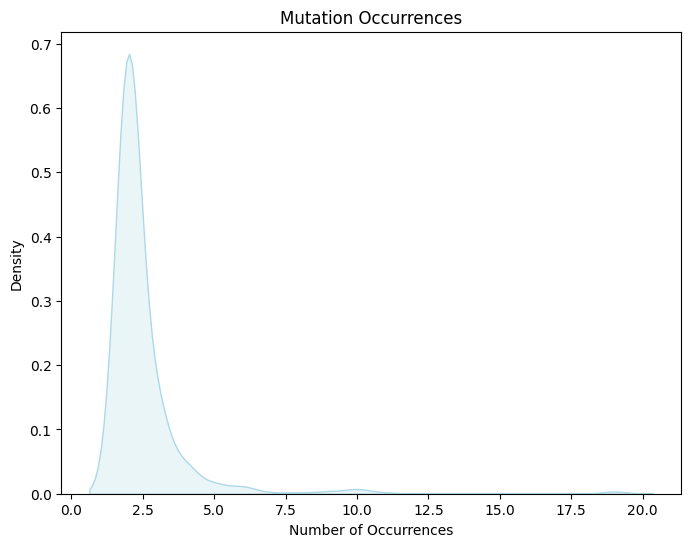

In [ ]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=recurrent_mut, x='Occurrences', fill = True, color = 'lightblue')
plt.title('Mutation Occurrences')
plt.xlabel('Number of Occurrences')
plt.show()

Store recurrent mutations in a dictionary, make a df of only recurrent mutations if needed.

# Statistics on DDGs
1. compute ddg
2. add column reporting ddg
3. plot ddg distribution

In [ ]:
mut_aff = skempi_4169['Affinity_mut_parsed'].to_numpy()
wt_aff = skempi_4169['Affinity_wt_parsed'].to_numpy()
dg_mut = (8.314/4184)*(273.15 + 25.0) * np.log(mut_aff)
dg_wt = (8.314/4184)*(273.15 + 25.0) * np.log(wt_aff)
ddg = (8.314/4184)*(273.15 + 25.0) * np.log(wt_aff/mut_aff)

In [ ]:
skempi_4169['ddg']=ddg

In [ ]:
skempi_4169['ddg'].head()

,ddg
0,-2.280577
1,-1.188776
2,-6.765446
3,-2.982502
4,-4.411843


In [ ]:
actual = s4169['actual']

In [ ]:
dfddg = s4169[['pdb', 'actual']]
dfddg.shape

(4169, 2)

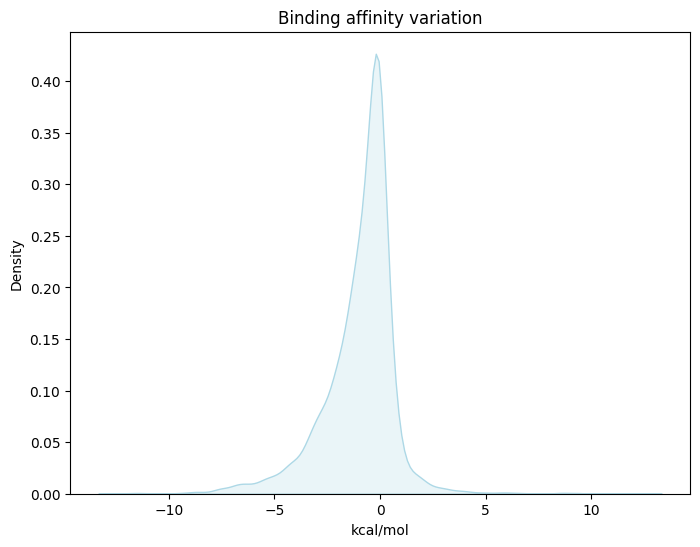

In [ ]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=dfddg, x='actual', color='lightblue', fill=True)
plt.title('Binding affinity variation')
plt.xlabel('kcal/mol')
plt.show()

In [ ]:
print(max(ddg))
print(min(ddg))

12.352226287325513
-12.352226287325513


In [ ]:
np.isnan(ddg).sum()
print(np.average(ddg[~np.isnan(ddg)]))

-1.0084978784717196


# PDB analysis

1. create file storing IDs
2. map it to uniprot
3. store pdb - uniprot in a dictionary/df
4. store uniprot - pdb in a dictionary/df
5. plot the 2 distributions (uniprot per pdb and pdb per uniprot)


In [ ]:
ids = skempi_4169['PDB'].to_list()
id = []
for el in ids:
  if el not in id:
    id.append(el)
#chain = skempi_4169['Chain'].to_list()
with open("PDBs.txt", "w") as writer:
  for el in id:
       writer.write(el+"\n")

In [ ]:
file_path = '/content/drive/MyDrive/dati/pdb_uniprotswprot.tsv'
try:
    uniprot = pd.read_csv(file_path, delimiter="\t")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

In [ ]:
uniprot

,From,Entry,Reviewed
0,1CSE,P00780,reviewed
1,1CSE,P01051,reviewed
2,1ACB,P01051,reviewed
3,1ACB,P00766,reviewed
4,1SBN,P00782,reviewed
...,...,...,...
653,1YQV,P00698,reviewed
654,3QIB,P04224,reviewed
655,3QIB,P04230,reviewed
656,3QIB,P00039,reviewed


In [ ]:
pdb_uniprot = uniprot.groupby('From')['Entry'].apply(list).to_dict()
print(pdb_uniprot)

{'1A22': ['P01241', 'P10912'], '1A4Y': ['P03950', 'P13489'], '1ACB': ['P01051', 'P00766'], '1AHW': ['P01837', 'P01868', 'P13726'], '1AK4': ['P12497', 'P62937'], '1AO7': ['P14079', 'A0A075B6T6', 'A0A0K0K1A5', 'A0A5B9', 'P01848', 'P01850', 'P04439', 'P61769'], '1B2S': ['P00648', 'P11540'], '1B2U': ['P00648', 'P11540'], '1B3S': ['P00648', 'P11540'], '1B41': ['P0C1Z0', 'P22303'], '1BD2': ['P14079', 'P0C213', 'A0A0K0K1A5', 'A0A5B9', 'P01848', 'P04437', 'P04439', 'P61769'], '1BJ1': ['P15692'], '1BP3': ['P01241', 'P16471'], '1BRS': ['P00648', 'P11540'], '1C1Y': ['P04049', 'P62834'], '1C4Z': ['P68036', 'Q05086'], '1CBW': ['P00766', 'P00767', 'P00974'], '1CHO': ['P68390', 'P00766'], '1CSE': ['P00780', 'P01051'], '1CSO': ['P00777', 'P68390'], '1CT0': ['P00777', 'P68390'], '1CT2': ['P00777', 'P68390'], '1CT4': ['P00777', 'P68390'], '1CZ8': ['P15692'], '1DAN': ['P08709', 'P13726'], '1DQJ': ['P01837', 'P01865', 'P00698'], '1DVF': ['P01635', 'P01646', 'P01820'], '1E50': ['Q01196', 'Q13951'], '1E96':

In [ ]:
uniids = uniprot['Entry'].to_list()
id = []
for el in ids:
  if el not in id:
    id.append(el)

print(len(id))

pdb = []
pdbids = uniprot['From']
for el in pdbids:
  if el not in pdb:
    pdb.append(el)

print(len(pdb))

tot = []
totuni = {}
unis = []
for el in pdb:
  tot.append(len(pdb_uniprot[el]))
  unis.append(pdb_uniprot[el])
  totuni[el]=len(pdb_uniprot[el])
pdbuni = pd.DataFrame({"PDB":pdb, "Uniprot":unis, "Uniprots":tot})

319
311


In [ ]:
pdbuni.shape

(311, 3)

In [ ]:
uniprot_pdb = uniprot.groupby('Entry')['From'].apply(list).to_dict()
print(uniprot_pdb)

{'A0A075B6T6': ['1AO7', '5E9D'], 'A0A0B4J279': ['2BNR', '2BNQ'], 'A0A0K0K1A5': ['1BD2', '1AO7', '2BNR', '2BNQ'], 'A0A5B9': ['1BD2', '1AO7'], 'A6ND01': ['5F4E'], 'A6QG59': ['3D5S', '3D5R'], 'B1Q236': ['4OFY'], 'B2RXS4': ['5E6P'], 'G0SCK6': ['5CXB', '5CYK'], 'G0SFB5': ['5CXB', '5CYK'], 'O00506': ['4NZW'], 'O08689': ['3SEK', '3HH2'], 'O08808': ['3EG5'], 'O14508': ['4JGH'], 'O14746': ['4MNQ'], 'O15085': ['5E6P'], 'O15151': ['3EQY'], 'O15357': ['2KSO'], 'O15392': ['3UIG', '3UII'], 'O43157': ['2REX'], 'O43924': ['5TAR'], 'O50147': ['3WWN'], 'O54901': ['4BFI'], 'O60486': ['3NVQ', '3NVN'], 'O75051': ['3Q3J'], 'O75326': ['3NVQ'], 'O95633': ['3SEK', '3B4V'], 'P00004': ['2PCB'], 'P00039': ['3QIB'], 'P00044': ['2B0Z', '2B10', '2B11', '2B12', '2PCC'], 'P00431': ['2B0Z', '2B10', '2B11', '2B12', '2PCC', '2PCB'], 'P00533': ['1YY9', '4KRL', '4KRO', '4KRP'], 'P00648': ['1BRS', '1B2U', '1B2S', '1B3S', '1X1W', '1X1X'], 'P00698': ['2I26', '1UUZ', '1VFB', '1KIQ', '1KIP', '1KIR', '1DQJ', '3HFM', '1XGU', '1XG

In [ ]:
uni_ids_for_df = []
pdb_lists_for_df = []
tot_pdbs_for_df = []

# Iterate through the uniprot_pdb dictionary which maps UniProt IDs to PDBs
for uni_id, pdb_list in uniprot_pdb.items():
    uni_ids_for_df.append(uni_id)
    pdb_lists_for_df.append(pdb_list)
    tot_pdbs_for_df.append(len(pdb_list))

unipdb = pd.DataFrame({
    "Uniprot": uni_ids_for_df,
    "PDB": pdb_lists_for_df,
    "Tot_pdb": tot_pdbs_for_df
})
unipdb.shape

(302, 3)

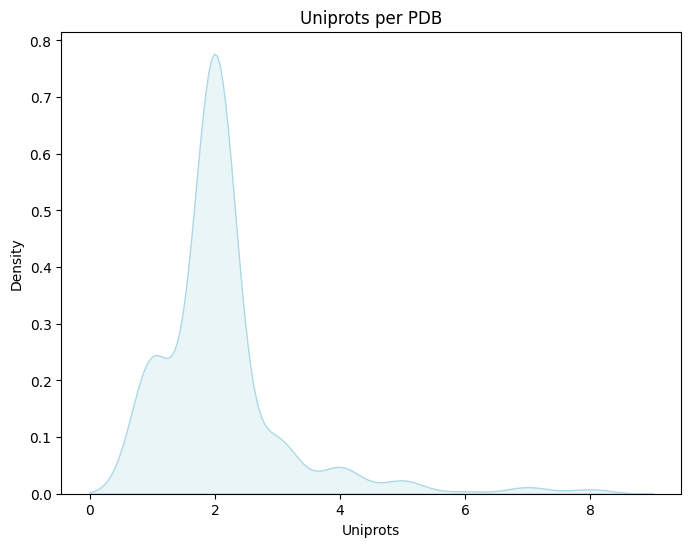

In [ ]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=pdbuni, x='Uniprots', fill=True, color = 'lightblue')
plt.title('Uniprots per PDB')
plt.xlabel('Uniprots')
plt.show()

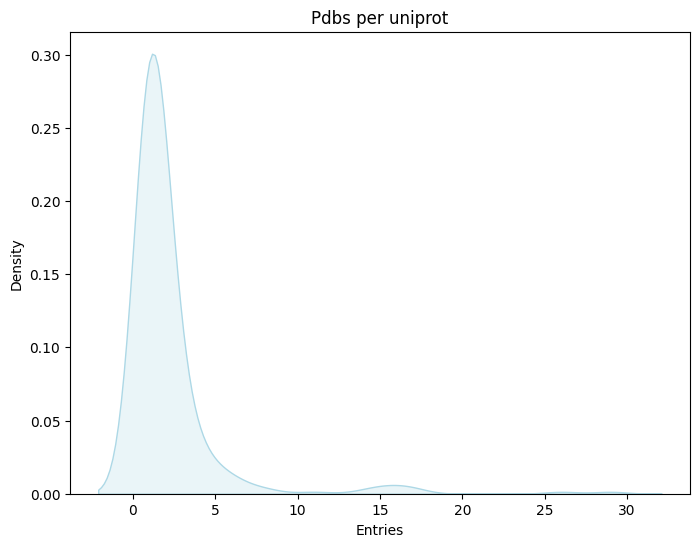

In [ ]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=unipdb, x='Tot_pdb', fill=True, color = 'lightblue')
plt.title('Pdbs per uniprot')
plt.xlabel('Entries')
plt.show()

In [ ]:
reviewed = uniprot[['Reviewed']].value_counts().to_dict()


In [ ]:
skempi_4169.shape

(4943, 37)

In [ ]:
skempi_4169.columns

Index(['#Pdb', 'Mutation(s)_PDB', 'Mutation(s)_cleaned',
       'iMutation_Location(s)', 'Hold_out_type', 'Hold_out_proteins',
       'Affinity_mut (M)', 'Affinity_mut_parsed', 'Affinity_wt (M)',
       'Affinity_wt_parsed', 'Reference', 'Protein 1', 'Protein 2',
       'Temperature', 'kon_mut (M^(-1)s^(-1))', 'kon_mut_parsed',
       'kon_wt (M^(-1)s^(-1))', 'kon_wt_parsed', 'koff_mut (s^(-1))',
       'koff_mut_parsed', 'koff_wt (s^(-1))', 'koff_wt_parsed',
       'dH_mut (kcal mol^(-1))', 'dH_wt (kcal mol^(-1))',
       'dS_mut (cal mol^(-1) K^(-1))', 'dS_wt (cal mol^(-1) K^(-1))', 'Notes',
       'Method', 'SKEMPI version', 'PDB', 'Chain', 'pdb', 'mutation', 'actual',
       'mcsm_ppi2_prediction', 'sampling_fold', 'ddg'],
      dtype='object')

In [ ]:
cleaned = skempi_4169[['#Pdb', 'PDB', 'Chain', 'Mutation(s)_PDB', 'Mutation(s)_cleaned', 'iMutation_Location(s)', 'Affinity_mut (M)', 'Affinity_mut_parsed', 'Affinity_wt (M)', 'Affinity_wt_parsed', 'actual', 'ddg',  'SKEMPI version', 'sampling_fold']]

In [ ]:
cleaned.shape

(4943, 14)

In [ ]:
cleaned['Uniprot']=''
for i in range(len(cleaned)):
  pdb_id = cleaned.loc[i, 'PDB']
  if pdb_id in pdb_uniprot:
    cleaned.loc[i,'Uniprot']= str(pdb_uniprot[pdb_id])[1:-1]
  else:
    cleaned.loc[i, 'Uniprot'] = ''

/tmp/ipykernel_32827/284582777.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned['Uniprot']=''


In [ ]:
cleaned

,#Pdb,PDB,Chain,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,actual,ddg,SKEMPI version,sampling_fold,Uniprot
0,1CSE_E_I,1CSE,I,LI45G,LI38G,COR,5.26E-11,5.260000e-11,1.12E-12,1.120000e-12,-2.281,-2.280577,1,2,"'P00780', 'P01051'"
1,1CSE_E_I,1CSE,I,LI45S,LI38S,COR,8.33E-12,8.330000e-12,1.12E-12,1.120000e-12,-1.189,-1.188776,1,2,"'P00780', 'P01051'"
2,1CSE_E_I,1CSE,I,LI45P,LI38P,COR,1.02E-07,1.020000e-07,1.12E-12,1.120000e-12,-6.765,-6.765446,1,2,"'P00780', 'P01051'"
3,1CSE_E_I,1CSE,I,LI45I,LI38I,COR,1.72E-10,1.720000e-10,1.12E-12,1.120000e-12,-2.982,-2.982502,1,2,"'P00780', 'P01051'"
4,1CSE_E_I,1CSE,I,LI45D,LI38D,COR,1.92E-09,1.920000e-09,1.12E-12,1.120000e-12,-4.412,-4.411843,1,2,"'P00780', 'P01051'"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4938,3QIB_ABP_CD,3QIB,P,KP9A,KP8A,COR,>1.1E-03,1.100000e-03,5.5E-06,5.500000e-06,-3.139,-3.138999,2,8,"'P04224', 'P04230', 'P00039', 'P01848'"
4939,3QIB_ABP_CD,3QIB,P,KP9R,KP8R,COR,2.4E-04,2.400000e-04,5.5E-06,5.500000e-06,-2.237,-2.237034,2,8,"'P04224', 'P04230', 'P00039', 'P01848'"
4940,3QIB_ABP_CD,3QIB,P,TP12A,TP11A,COR,>1.1E-03,1.100000e-03,5.5E-06,5.500000e-06,-3.139,-3.138999,2,8,"'P04224', 'P04230', 'P00039', 'P01848'"
4941,3QIB_ABP_CD,3QIB,P,TP12S,TP11S,COR,3.38E-05,3.380000e-05,5.5E-06,5.500000e-06,-1.076,-1.075723,2,8,"'P04224', 'P04230', 'P00039', 'P01848'"


In [ ]:
cleaned.to_csv('dataset.tsv', sep = '\t')

In [ ]:
locations = cleaned['iMutation_Location(s)'].value_counts().to_dict()
len(locations)

5

In [ ]:
locations_df = pd.Series(locations).reset_index()
locations_df.columns = ['Location', 'Count']
print(locations_df.shape)

(5, 2)


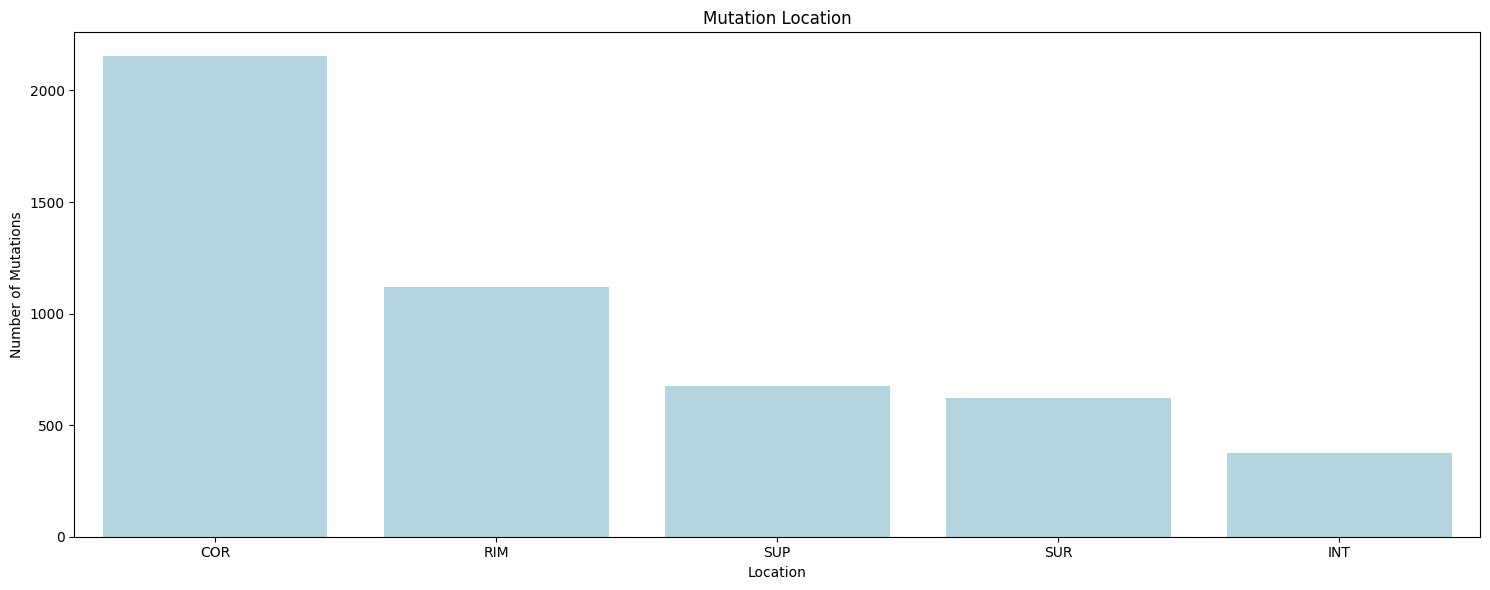

In [ ]:
locations_sorted = locations_df.sort_values(by='Count', ascending=False)

# Convert the 'Mutations' tuples to string representations for plotting
plt.figure(figsize=(15, 6))
sns.barplot(x='Location', y='Count', data=locations_sorted, color = 'lightblue', fill=True,  legend=False)
plt.title('Mutation Location')
plt.xlabel('Location')
plt.ylabel('Number of Mutations')
plt.tight_layout()
plt.show()

In [ ]:
for key in locations:
  print(key, ": ", locations[key])

COR :  2153
RIM :  1118
SUP :  675
SUR :  623
INT :  374


In [ ]:
method = skempi_4169['Method'].value_counts().to_dict()

methods = []
entries = []
for key in method:
  methods.append(key)
  entries.append(method[key])

methods = pd.DataFrame({"Method":methods, "Entries":entries})
methods.shape


(20, 2)

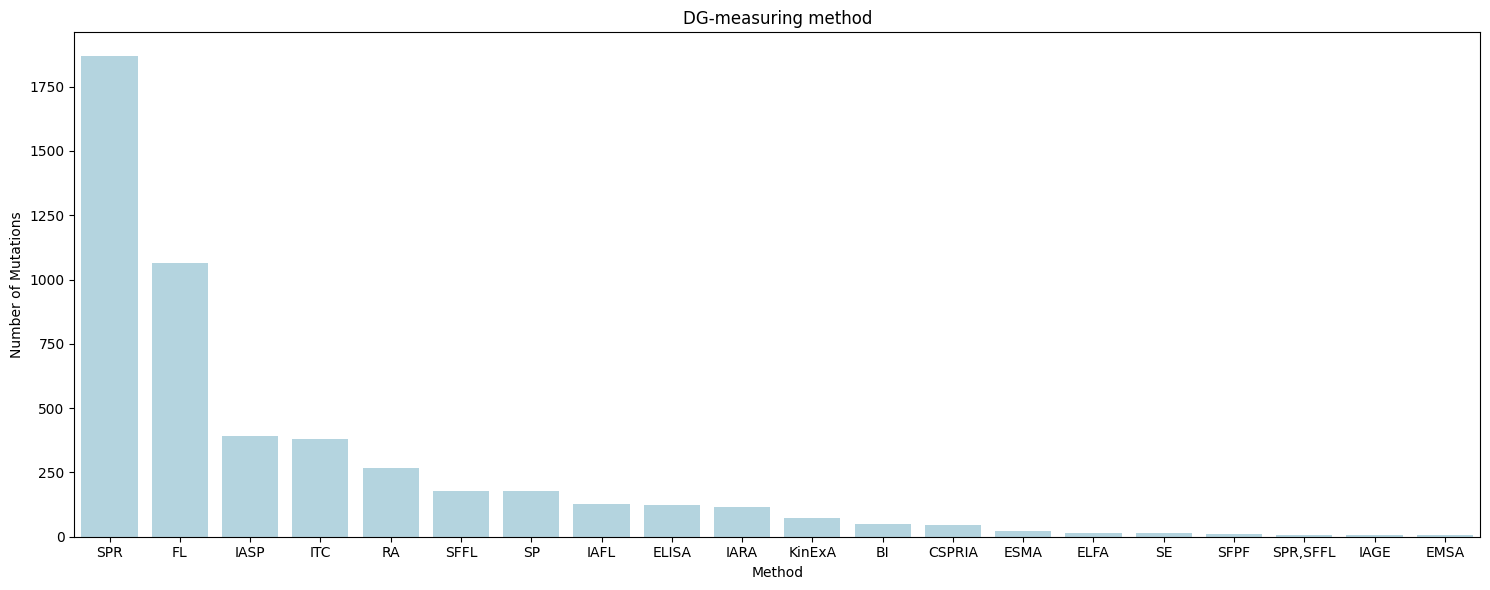

In [ ]:
methods_sorted = methods.sort_values(by='Entries', ascending=False)

# Convert the 'Mutations' tuples to string representations for plotting
plt.figure(figsize=(15, 6))
sns.barplot(x='Method', y='Entries', data=methods, color = 'lightblue', fill=True,  legend=False)
plt.title('DG-measuring method')
plt.xlabel('Method')
plt.ylabel('Number of Mutations')
plt.tight_layout()
plt.show()

In [ ]:
for key in method:
  print(key, ": ", method[key])

SPR :  1868
FL :  1065
IASP :  392
ITC :  379
RA :  268
SFFL :  178
SP :  178
IAFL :  127
ELISA :  125
IARA :  117
KinExA :  74
BI :  48
CSPRIA :  44
ESMA :  21
ELFA :  15
SE :  13
SFPF :  10
SPR,SFFL :  8
IAGE :  7
EMSA :  6
